ESCI 895- Final Project- Mississippi River Sediment Deposition, 
Amelea Hauer, 
Fall 2025 
---------------------------------------------------------------------------------------------

---------------------------------------------------------------------------------------------
Introduction: This project examines the estimated annual sediment deposition into the Gulf of Mexico from the Mississippi River over the last 10 years. In the project, data analysis will be conducted using Python to estimate annual sediment flux from the Mississippi River into the Gulf of Mexico, using data from the USGS Baton Rouge monitoring station, the last non-tidal USGS station upstream of the Gulf of Mexico. Statistical analyses will be done to explore the discharge, sediment fluxes, sediment transport, and seasonality of the data. This project has applicability to the world outside of just python, that being the coastline of of Louisiana and surrounding states in the Gulf of Mexico. The deposition and reworking of sediments is crucial in preserving the shoreline from erosional processes (high-energy beach environments, storm-surge, precipitation/storm outwash, etc.). The artifical levees of the Mississippi have helped to prevent flooding events along the Mississppi River, but have in return disconnected the natural processes of floodplains. The nearby floodplains and coasts have been decreasing in surface area and elevation due to the levees disrupting sediment deposition. This has caused large scale water inundation coupled with sea level rise and landward elevation fall. The Mississippi river has been anthropogenically impacted by more than just the levees; it has intermittent dams along its continuum. The dams affect the river's velocity, discharge, and sediment transport. Therefore, the natural processes of the river have been changed overtime, and studying the sediment deposition has important links to the ecosystem, natural habitats, coastline, and anthropogenic factors. Therefore, in this project analysis will be done on the last ten years and will look for any annual and/or seasonal patterns in the USGS data.

---------------------------------------------------------------------------------------------
Research Question: How has the sediment flux to the Gulf of Mexico via the Mississippi River changed over the last ten years?
------------------------------------------------------------------------------------------------

*Has the sediment flux increased or decreased throughout the study?

*Is there a significant correlation of increased discharge with increased sediment transport? 

*Is there seasonality shown in the data?

------------------------------------------------------------------------------------------------

Data includes USGS: monitoring station gauge, Mississippi River at Baton Rouge, LA - USGS-07374000 between the entire water years of 2015-2025 

Data started being collected at this site from 2004-03-17 to 2025-12-04 (current day) and is recorded at fixed 15 minute intervals. However, when the USGS data is downloaded for use it is in daily measurements. 

River Discharge : the volume of water flowing per unit of time
*USGS parameter code : 00060

Turbidity : a measure of how much suspended solid is in the water volume. In units of 1 NTU (Nephelometric Turbidity Unit), which is a measure of how much suspended particles are in the water volume, measured by a nephelometer, a scientific device that shoots a light beam at a 90 degree angle through the water and the light scatter is measured. The more scatter/murkiness = higher NTU = higher turbidity
*USGS parameter code : 63680

Below displays the data used from the USGS file. The mean values were used in this study rather than the maximums & minimums which were disregarded. That is because the means better capture the "story" of the data.

        TS   parameter     statistic     Description
        
    215574       63680     00003     Turbidity, water, unfiltered, monochrome near infra-red LED light, 780-900 nm, detection angle 90 +-2.5 degrees, formazin nephelometric units (FNU) (Mean)
    
     61176       00060     00003     Discharge, cubic feet per second (Mean)
------------------------------------------------------------------------------------------

Study site: Mississippi River at Baton Rouge, LA. 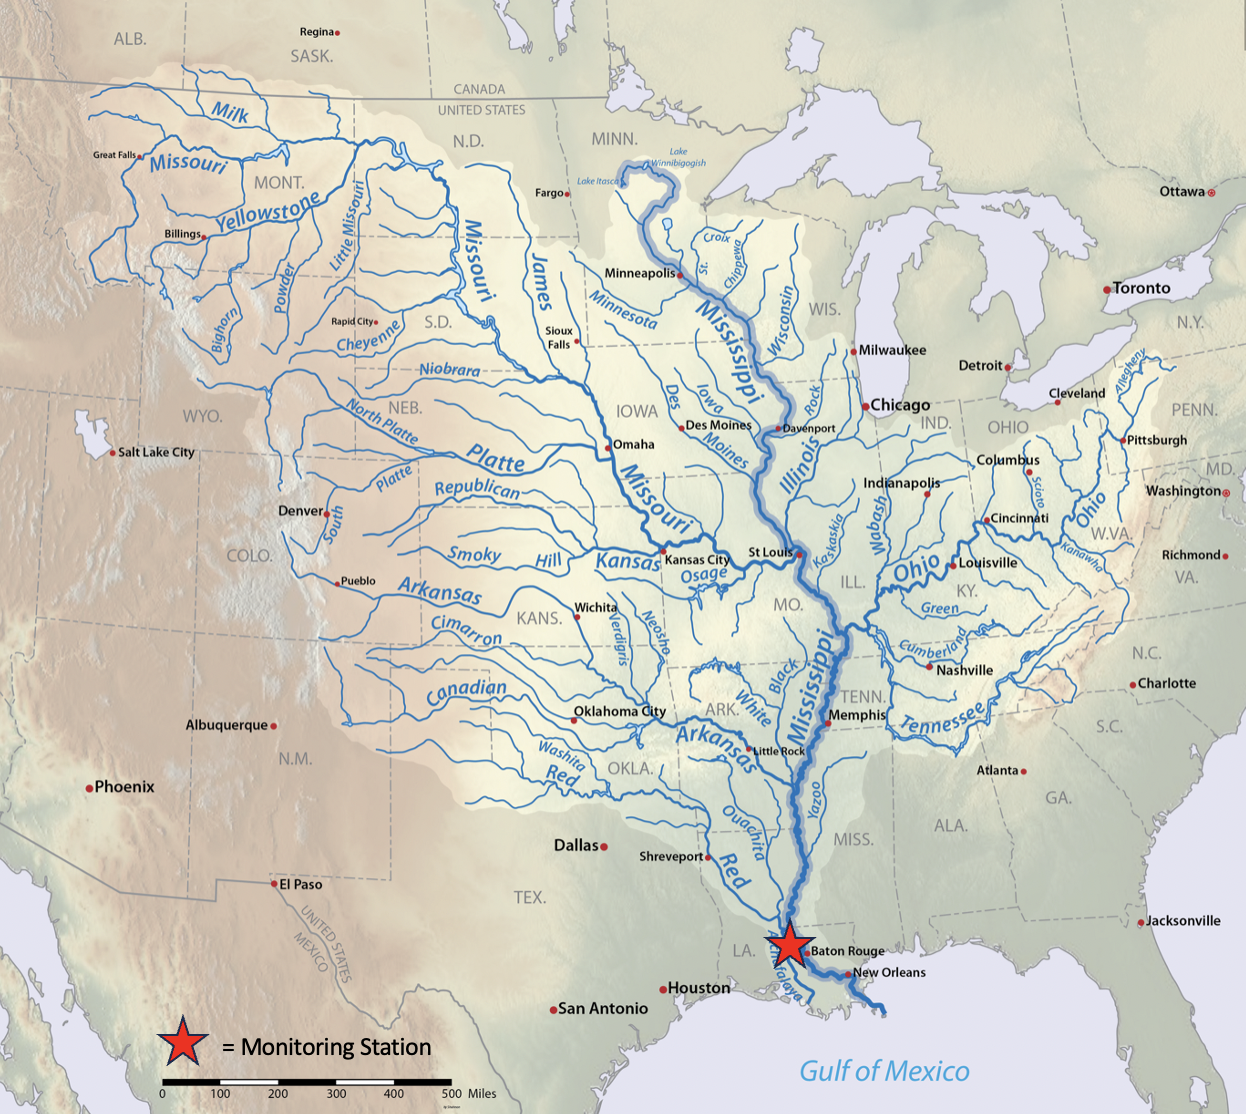 Image 2: Showing the location of Baton Rouge, LA, in comparison to the USA, also including the pathway of the entire Mississippi and its feeding waterways. The monitoring station in this dataset is one of the most southern stations on the Mississippi and was chosen for that reason, in hopes of capturing a realistic and accurate number of accumulated sediment transport, which is close to the terminus and is not affected by tides. 

Study site: Mississippi River at Baton Rouge, LA. 
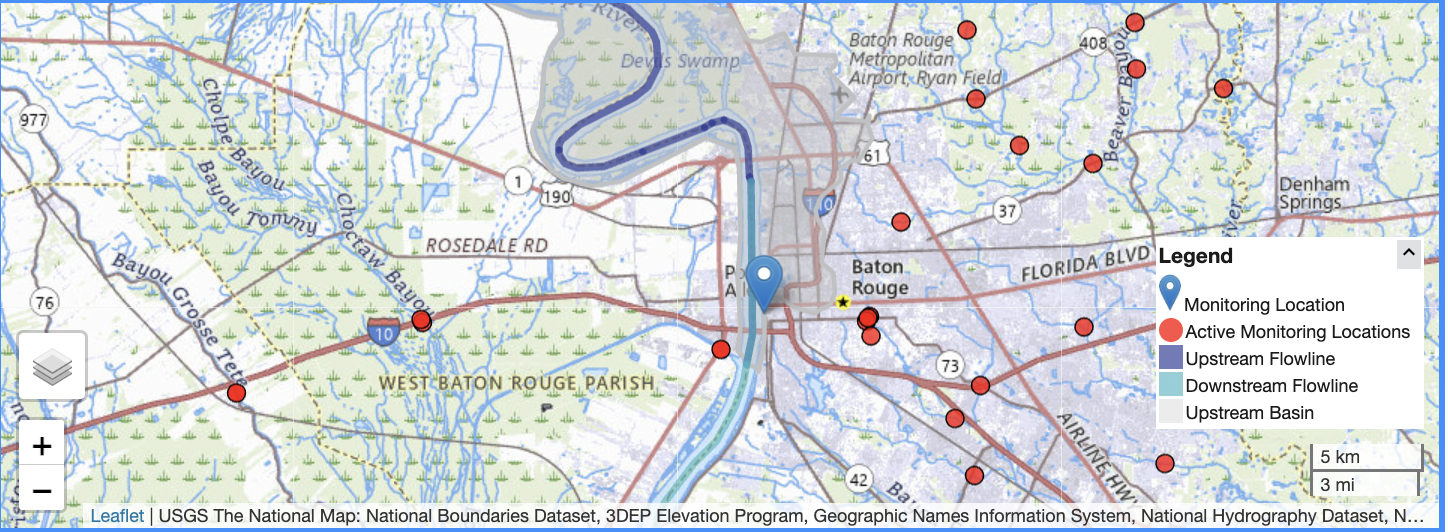
Image 1: Above depicts the location of the USGS station from the USGS site. The monitoring station is shown by the light blue pin. 

Imports

In [24]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from datetime import datetime
import matplotlib.dates as plotdate
import matplotlib.pyplot as plt
import sys 
import os
from pathlib import Path
folder_path = Path(os.getcwd()).parent.parent/'src'
sys.path.append(folder_path)
from scipy import stats

Parameters

In [25]:
cwd = os.getcwd()
data_usgs = Path(cwd)/ 'USGS data.txt'

ft3_to_m3 = 0.0283168 #conversion for ft3 to m3 
m3_s = 1
l_m3 = 1000  #liter to m3
kg_mg = 0.000001 #kg to mg
mg_l_to_kg_m3 = 0.001 #mg/l to kg/m3
sec_per_day = 24 * 60 * 60   # 86400 secs in a day 

This function's purpose is to read in the USGS data from the Baton Rouge, LA monitoring gauge and manipulate the data. The gauge's data includes: discharge (converted from ft3/s -> m3/s) and turbidity (NTU). The data in this function will be used in calculations and plotting further in along in the coding project. 

Specifics of the function: reads usgs data -> converts the date & time to the index -> keeps the data of discharge & turbidity (mean of the data) -> renames the columns for easy identitification -> converts discharge from ft3/s to m3/s -> converts to water year 

Conversion of data : (ft3/s) * (0.028m^3/1ft^3) = m3/s

In [26]:
#%%reading in USGS data
def read_in_usgs(filename):  
    """
    Parameters
    ----------
    filename : USGS data (in tab-deliminated form(txt))
    
    Returns   
    -------    
    dataframe with datetime as index, turbidity, and discharge
    df with datetime index, discharge (ft3/s)
    turbidity (NTU), water year, and discharge converted discharge m3/s)
    """
    #read data in   
    
    usgs_data = pd.read_csv(filename, comment="#", sep="\t", skiprows=36) #want to skip lines until headings
    usgs_data = usgs_data.iloc[1:,:]
    
    #convert datetime to index
    
    usgs_data["datetime"] = pd.to_datetime(usgs_data["datetime"], errors='coerce') #make datetime into real dates and time
    usgs_data.set_index("datetime", inplace=True) #set new index as datetime
    
    #cols to keep that are needed (USGS codes for discharge, turbidity)
    cols_to_keep = [] #to store cols I want 
    
    for name in usgs_data.columns.tolist():  # discharge and turbidity data, only keeping mean values, throwing out max and min values
        if ((("00060" in name) or ("63680" in name))
            and (("00003" in name) and ("cd" not in name))):
            cols_to_keep.append(name)    
    
             
    good_data= usgs_data[cols_to_keep].apply(pd.to_numeric, errors='coerce') #puts good columns in good_data df, also makes them numbers
            
    #renaming cols 
    
    new_names = {} #makes it a "dictionary" to put new names in 
    for name in good_data.columns:
        if "00060" in name:
            new_names[name] = "discharge (ft^3/s)"
        elif "63680" in name:
            new_names[name] = "Turbidity"
        else:
            new_names[name] = name
            
    good_data.rename(columns=new_names, inplace=True)
    
    #conversions 
    
    def vol_ft3_to_area_m(discharge_ft3s): #conversion ft3/s to m3/s
            discharge_m = discharge_ft3s * ft3_to_m3  # ft3 -> m3
            return discharge_m
       
    if "discharge (ft^3/s)" in good_data.columns:
        good_data["discharge_m3/s"] = vol_ft3_to_area_m(good_data["discharge (ft^3/s)"]) #discharge in m/day units
    
    #water year conversion
     
    good_data['wateryear'] = np.where(good_data.index.month >= 10,   #definition october 1 (year)- september 30 (year+1))
                            good_data.index.year +1,
                            good_data.index.year) #water year parameters, switch from month 9 to 10 
    

    good_data = good_data.loc["2015-10-01" : "2025-09-30"] #want data for full water years
    
    return(good_data)

#reassign dataframe, use good_data (more simplified)
good_data = read_in_usgs(data_usgs)


-----------------------------------------------------------------------

Function's purpose: To calculate linear regression analyses that are both parametric and non-parametric (Theil-Sen & Kendall-Tau). Also, plots and makes a best line fit. 

R value: Strength of the relationship & how well the data fit the best-fit line, r=1 (perfect relationship), r=0 (no relationship). Important for measuring how strong the phsycial relationship is. 

P value: Statistical significance & tests if the relationship is "real" or random noise (lots of random data with no correlation). p < 0.05 means relationship is statistically significiant (there is correlation). Important for testing a hypothesis and showing signficiance. 

In [27]:
#%% linear regression calculation 

def lin_reg(x,y, xlabel, ylabel, title):
    """
    scatter plot with regression
    best fit line calculated using linear and theil-sen techniques
    confidence interval for regression slope using linear and theil-sen technqiues 
    p value for linear and theil-sen techniques
    
    """
    plt.figure()
    
    y = pd.DataFrame(y)
    x = pd.DataFrame(x)
    
    prop_cycle = plt.rcParams['axes.prop_cycle']
    colors = prop_cycle.by_key()['color']
    
    for i, y_col in enumerate (y.columns.tolist()):
        print(colors[i])
        if min(x.shape) == 1:
            new_df = pd.DataFrame({'x': x.values.ravel() , 'y': y[y_col].values }).dropna() 
        else:
            new_df = pd.DataFrame({'x': x[y_col].values , 'y': y[y_col].values }).dropna() 
        x_good = new_df['x'].values #no nans 
        y_good = new_df['y'].values #no nans
        
        #parametric linear regression
        lsq = stats.linregress(x_good, y_good)
    
        # Parametric Linear Regress
        lsq = stats.linregress(x_good, y_good)
       # print(f"Parametric linear regression: {y_good} vs {x_good}")
        print(f"slope: {lsq.slope:.3f}")
        print(f"intercept: {lsq.intercept:.3f}")
        print(f"r-value: {lsq.rvalue:.3f}")
        print(f"p-value: {lsq.pvalue:.3e}")
        print(f"standard error: {lsq.stderr:.3f}")
        print(f"95% CI slope: [{lsq.slope - 2*lsq.stderr:.3f}, {lsq.slope + 2*lsq.stderr:.3f}]")
    
        # Nonparametric Theil–Sen Regression 
        ts = stats.theilslopes(y_good, x_good, 0.95)
        print(f" Theil–Sen regression:")
        print(f" slope: {ts.slope:.3f}")
        print(f" intercept: {ts.intercept:.3f}")
        print(f" 95% CI slope: [{ts.low_slope:.3f}, {ts.high_slope:.3f}]")
    
        # Kendall Tau
        tau = stats.kendalltau(x_good, y_good)
        print(f" Kendall Tau correlation: {tau.statistic:.3f}")
        print(f"  p-value: {tau.pvalue:.3e}")
    
        #Plot 
        if min(y.shape) == 1:
            
            plt.scatter(x_good, y_good, color= 'black', label='data', s=3)
        else: 
            plt.scatter(x_good, y_good, color= colors[i], label=y_col, s = 3)
    
    
        #Fit lines
        x_fit = np.linspace(np.min(x_good), np.max(x_good), 100)
        y_fit_lin = lsq.intercept + lsq.slope * x_fit
        y_fit_ts = ts.intercept + ts.slope * x_fit
    
        if min(y.shape) == 1:
            plt.plot(x_fit, y_fit_lin, color='red', label='Linear regression (parametric)')
            plt.plot(x_fit, y_fit_ts, color='blue', linestyle='--', label='Theil–Sen (non-parametric)')
        else:
            plt.plot(x_fit, y_fit_lin, color=colors[i])
            plt.plot(x_fit, y_fit_ts, color=colors[i], linestyle='--')

    #plotting 
    plt.xlabel(xlabel) 
    plt.ylabel(ylabel) 
    plt.title(title if title else f"{y_good} vs {x_good}") 
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

-----------------------------------------------------------------------
Total Suspended Solids (tss)

The total suspended solids(tss) concentration calculation used in this project was borrowed from the paper "A hyperspectral view of the nearshore Mississippi River Delta: Characterizing suspended particles in coastal wetlands using imaging spectroscopy" by Harringmeyer et al in 2024. The equation was derived for converting measured turbidity into total suspended solids in the Mississippi River. Turbidity is the measure of how much reflectance there is in a water column, hence the higher reflectance meaning more particles in the water column, which means higher turbidity, and vice versa. Turbidity and tss are therefore correlated, with a specific derived equation for the specififed river one can convert turbidity measurements to an estimated tss. Different rivers have different parameters within the equation because of differences in their surrounding environment, such as discharge amount, geomorphology contrbuting to sediment input, and locks & dams to name a few. The equation's parameters are based off regression coefficients (slope and intercept) from a linear calibration between the turbidity and tss from the past study of Harringmeyer et al on the Mississippi. The equation is used in this project because USGS has data in turbidity but not in tss or sediment flux. Therefore, to figure out the sediment flux and transport, turbidity must be converted into tss for further examination. The equation used is shown below. 

Concentration calculation 
EQUATION: TSS = 1.913 * Turbidity - 2.141  (Harringmeyer et al 2024)

1.913 = slope = strength of the relationship (mg/l change per NTU)

-2.141 = intercept = model offset at 0 NTU

turbidity in formazin nephelometric units (NTU),
TSS = total suspended solids in mg/L

In [28]:
#%% tss concentration calculation 

good_data['tss'] = 1.913 * good_data['Turbidity'] - 2.141 #calculated tss from turbidity 
    

Converting the units of tss from mg/l to kg/m3. 

In [29]:
#%%tss conversion from mg/l to kg/m3 

def tss_mgL_to_kg_m3(mg_l):
    """
    Convert TSS from mg/L to kg/m3.
    """
    kg_m3 = mg_l * mg_l_to_kg_m3
    return kg_m3

# Apply to your dataframe
good_data['tss_kg_m3'] = good_data['tss'].apply(tss_mgL_to_kg_m3)

-----------------------------------------------------------------------
SEDIMENT FLUX

Calculating sediment flux...flux = concentration x discharge, so sediment flux = tss x discharge. 

sediment flux (kg/s) = tss (kg/m3) * discharge (m3/s)

The sediment flux is a measure of how much sediment (tss) is being moved by the water at the time of measurement, it is the observed sediment mass flow rate per timestamp . This is calculated to understand how much sediment is being moved by the river's discharge. In this project, the focus is on understanding how much sediment is being transported and deposited into the Gulf of Meixo via the Mississippi. Therefore, this calculation is crucial to answering this question. 

Meaning: The observed sediment mass flow rate per day.

Use: It will be used for the annual sediment load calculations (kg/year) from the Mississippi river to the Gulf of Mexico.

Advantage: Sediment flux is a simple calculation that can model the sediment flux of the Mississippi River.

Disadvantage: It has uncertainty due to only one known measured variable (discharge), while tss was derived from turbidity creating a source of error and assumption in the calculation. Also, this data is quite noisy with large fluctuations making trends sometimes hard to see. 

Question: Are the discharge and sediment flux statsistically correlated? Do they show an upward or downward trend over the study's duration? 

In [30]:
#%% Calculating sediment flux in units of kg/s  

good_data['sediment_flux_kg/s'] = good_data['tss_kg_m3'] * good_data['discharge_m3/s'] 

--------------------------------------------------------------
SEDIMENT TRANSPORT

Wolman & Miller constructed an equation to solve for sediment transport and that was the transport formula : 𝑇 = aQ^b , Where it is a fitted power-law rating curve : T = sediment transport, Q = discharge, a, b = coefficients from fitting log–log regression. 

$$
T = a\,Q^{b}
$$

The sediment transport calculation was necessary for modeling the sediment transport rate to later plot in the Wolman & Miller plot later on in the report. It is based upon the sediment flux (dependent variable) calculated prior and inlcudes discharge (independent variable). The regression values of a and b are based off the relationship between discharge and sediment flux, to later become the value of sediment transport. 

Meaning: The modeled sediment transport rate based on the discharge and sediment flux. It is a more complex calculation for estimation of hwo much sediment is being moved through river channel by incorporating the discharge, sediment flux, and coefficients which are derived from the log-log regression between sediment flux and discharge. Advantage: This data is more smooth and predictable, as in knowing that more sediment transport will happen with increased discharge and sediment flux. Disadvantage: There is larger uncertainty in values due to the conversion of turbidity -> tss -> sediment flux -> sediment transport. This could result in an inccurate modeled numbers leading to possible overestimation or underestimation. 

Advantage: This data is more smooth and predictable and provides an output for sediment transport. 

 Disadvantage: There is larger uncertainty in values due to the conversion of turbidity -> tss -> sediment flux -> sediment transport. This could result in an inccurate modeled numbers leading to possible overestimation or underestimation. 

In [31]:
#%calculating sediment transport formula:  T = aQ^b    
#Where:T = sediment transport, Q = discharge, a, b = coefficients from fitting log–log regression
#AI helepd me with the filter step. 

Q = good_data['discharge_m3/s'] #discharge in m3/s 
T = good_data['sediment_flux_kg/s']   # sediment flux kg/s

filter = (Q > 0) & (T > 0) & np.isfinite(Q) & np.isfinite(T) #had no values in cols, so filtering out 
Q_filter = Q[filter]
T_filter = T[filter]

coeffs = np.polyfit(np.log(Q_filter), np.log(T_filter), 1) # caclulating: log(T) = log(a) + blog(Q)

b = coeffs[0]
a = np.exp(coeffs[1])

good_data['sed_transport_kg/s'] = a * (Q ** b) #sediment transport calculation 

In [32]:
#%%sediment transport grouped by water year 

sed_transport_kg_wy = good_data.groupby('wateryear')['sed_transport_kg/s'].sum() #sed transport summed over a water year 

good_data['sed_transport_kg_wy'] = good_data['wateryear'].map(sed_transport_kg_wy) #putting into df

print(sed_transport_kg_wy)

wateryear
2016    7.038339e+05
2017    5.458381e+05
2018    5.768215e+05
2019    1.185848e+06
2020    9.280986e+05
2021    5.615425e+05
2022    4.972683e+05
2023    3.811842e+05
2024    4.073047e+05
2025    5.315548e+05
Name: sed_transport_kg/s, dtype: float64


---------------------------------------------------------------------
Calculations

Calculations of mean, max, min done for the discharge, tss, sediment flux, and sediment transport for the water year. These calculations were not used for any statistical analysis, but rather for comparative analysis. In other words, a superfificial glance at the data before plotting. 

In [33]:
#%%Calculations mean, max, min done for the discharge, tss, sediment flux, and sediment transport for the water year.

types = ['discharge_m3/s', 'tss_kg_m3', 'sed_transport_kg/s', 'sediment_flux_kg/s' ] #variables that calculations will be based off

for variables in types: 
    average_wy = good_data.groupby('wateryear')[variables].mean() #mean for wy
    min_wy = good_data.groupby('wateryear')[variables].min() #min for wy
    max_wy = good_data.groupby('wateryear')[variables].max() #max for wy

    #water year averages as a new column in good_data
    good_data[f'average of {variables} in wateryear'] = good_data['wateryear'].map(average_wy)
    good_data[f'minimum of {variables} in wateryear'] = good_data['wateryear'].map(min_wy)
    good_data[f'maximum of {variables} in wateryear'] = good_data['wateryear'].map(max_wy)
    

--------------------------------------------------------------------
FIGURES BELOW

--------------------------------------------------------------------
TIMESERIES OF RAW COMPILED DATA (discharge, tss, sediment flux, sediment transport)

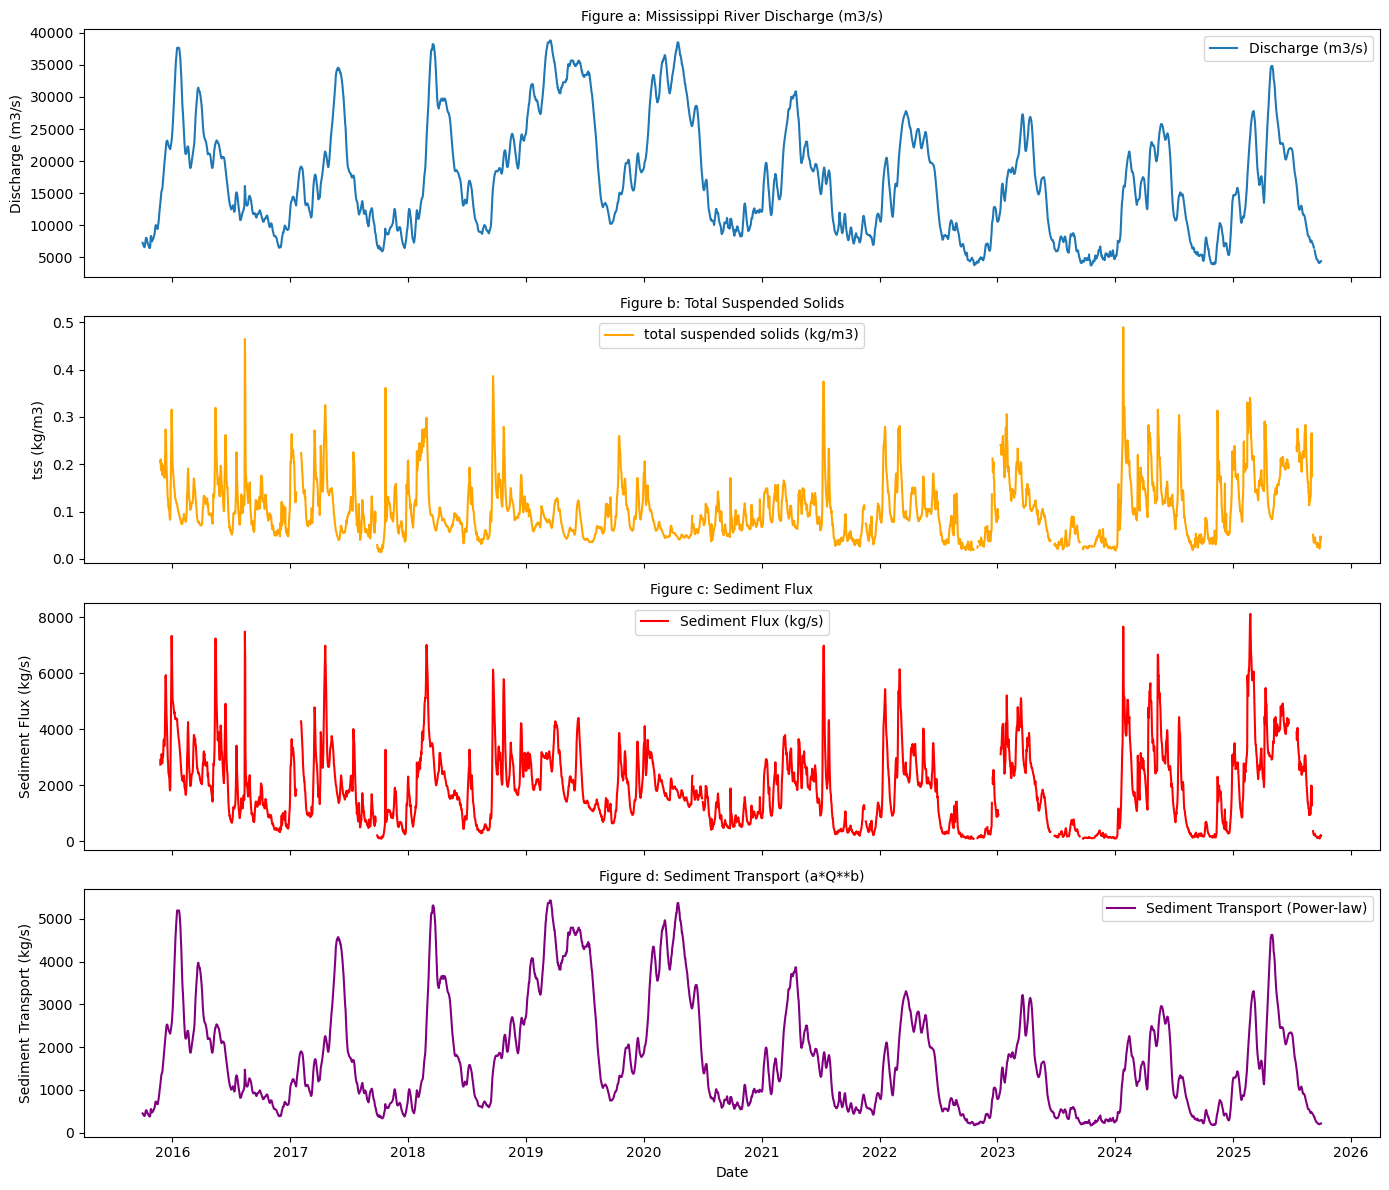

In [34]:
#%% #Timseries subplot of discharge, tss, sed flux, sed transport 

fig, axs = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
axs = axs.flatten()

Q  = good_data['discharge_m3/s']
TSS = good_data['tss_kg_m3']
SF  = good_data['sediment_flux_kg/s']
ST = good_data['sed_transport_kg/s']

axs[0].plot(good_data.index, Q,linestyle='-', label='Discharge (m3/s)') #discharge m/day
axs[0].set_title("Figure a: Mississippi River Discharge (m3/s)", fontsize=10)
axs[0].set_ylabel("Discharge (m3/s)")
axs[0].legend()

axs[1].plot(good_data.index, TSS, linestyle='-', color='orange',label='total suspended solids (kg/m3)' )
axs[1].set_title("Figure b: Total Suspended Solids", fontsize=10)
axs[1].set_ylabel("tss (kg/m3)")
axs[1].legend()

axs[2].plot(good_data.index, SF,linestyle='-', color='red',label='Sediment Flux (kg/s)') #sediment flux
axs[2].set_title("Figure c: Sediment Flux", fontsize=10)
axs[2].set_ylabel("Sediment Flux (kg/s)")
axs[2].legend()

axs[3].plot(good_data.index, ST,linestyle='-', color='purple',
            label='Sediment Transport (Power-law)') #Sed transport (power-law model)
axs[3].set_title("Figure d: Sediment Transport (a*Q**b)", fontsize=10)
axs[3].set_ylabel("Sediment Transport (kg/s)")
axs[3].set_xlabel("Date")
axs[3].legend()

plt.tight_layout()
plt.show()

Discussion: The figure above depicts the raw data in a timeseries plot of the discharge, tss, sediment flux, and sediment transport from the water years 2015-10-01 : 2025-09-30. It is to show the data's spread over the study period. From this plot it can be seen that there is seasonality trend. A stronger trend shown in the discharge and sediment transport and a weaker trend with the tss and sediment flux. Seeing this plot is what redirected the study slightly from just an annual perspective to including a seasonal perspective, and that is due to two reasons. 1) It is not clearly apparent that the data is increasing or decreasing on a noticeably large scale throughout the study, but seasonality is strong. 2)It would be important to know during what seasons and/or months the largest values are annually happening to alert the public of dangerous flooding events. The seasons/months cannot be depicted from this x-axis because it is in water years. A noticeable feature of this plot is that there is not a strong correlation or one at all between discharge and sediment transport vs tss and sediment flux. When one is high the other tends to not be synchronous with it. This plot is the first part of the Mississippi River sediment deposition story.

-------------------------------------------------------------------
SEDIMENT FLUX

#1f77b4
slope: 0.095
intercept: 265.529
r-value: 0.603
p-value: 0.000e+00
standard error: 0.002
95% CI slope: [0.090, 0.099]
 Theil–Sen regression:
 slope: 0.115
 intercept: -85.428
 95% CI slope: [0.111, 0.119]
 Kendall Tau correlation: 0.585
  p-value: 0.000e+00


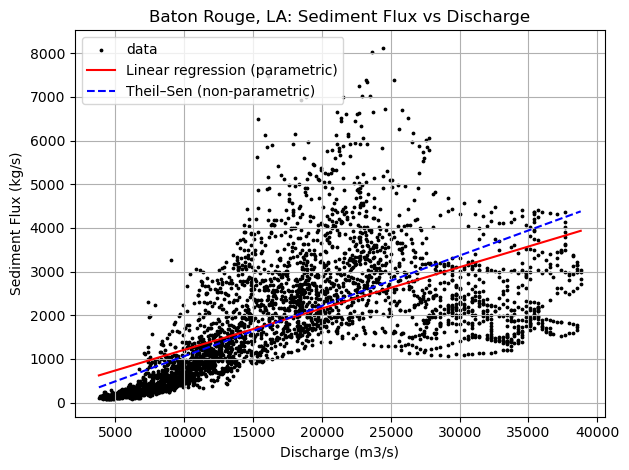

In [35]:
#%%Figure:Sediment flux (kg/s) vs Discharge (m³/s) Baton Rouge, LA 

lin_reg(good_data['discharge_m3/s'], good_data['sediment_flux_kg/s'],
        xlabel='Discharge (m3/s)', ylabel='Sediment Flux (kg/s)',
        title='Baton Rouge, LA: Sediment Flux vs Discharge')

Discussion: This figure explores the relationship between the sediment flux vs discharge. This is important for understanding how much sediment is being moved with various amounts of discharge flows. In general the most sediment is moved with moderate discharge flows. This is the next chapter of the raw data to the hydrologic story of the Mississippi because it helps to understand if there is an overall correlation between discharge and sediment flux.

Statistics Discussion: When comparing sediment flux vs discharge there is a moderate-strong relationship between the two. When discharge increases so does the sediment flux, this is reasonable to think since more water moving is able to move more sediment. However, above 27500 m3/s there seems to be a decrease in the sediment flux. The reason is unknown for this, but a possible reason could be that the turbidity sensor cannot accurately record when there are high amounts of discharge. Another, could be that with such high discharge there is a dillution effect of the sediment flux. In the literature it says,"This is appropriate because maximum sediment loads generally do not coincide with peak flood discharges," and this aligns with what is seen above, however there is not a state explanation for this (Wolman & Miller 1960).

R value = 0.603 =  a moderate-strong correlation between discharge * sediment flux, as discharge increases, sediment flux generally increases too. However, there is a substantial amount of noisiness and scatter in the data. 
Interpretation: The noisiness is normal in this type of data due to weather changes, such as storms, hysteresis, and sediment supply changes. The sediment flux could be influenced by other factors besides just discharge.

P Value = 0.000e+00 = extremely signficiant, the probability this happened by random is not likely, it is signficant. Discharge is an indicator of sediment flux, meaning they are correlated. It is important to note there are many data points which can cause high signficance in p values when r values are not always high. 

---
Investigating seasonality 

Below are the seasonal date ranges for binning the data and exploring seasonality. The seasons were split up to study seasonality patterns. As in, exploring to see if certain seasons had higher discharges or sediment fluxes. 

Questions: Were some seasons drier? Were some wetter? What season had the highest sediment flux? 

In [36]:
#%%Binning seasons 
#Winter = Jan, Feb, Mar 01-01 : 03:31
#Spring = April, May, June 04-01 : 06-30
#Summer = July, Aug, Sept 07-01 : 09-30
#Fall = Oct, Nov, Dec 10-01 : 12:31

def season(month):
    if month in [1, 2, 3]:
        return 'winter'
    elif month in [4, 5, 6]:
        return 'spring'
    elif month in [7, 8, 9]:
        return 'summer'
    elif month in [10, 11, 12]:
        return 'fall'

good_data['season'] = good_data.index.month.map(season) #putting season names into df

In [37]:
 #%%seasonal flux table with the average of season within a water year

seasonal_flux_table = good_data.pivot_table(index='wateryear',columns='season',
                      values=['sediment_flux_kg/s','discharge_m3/s'])
print(seasonal_flux_table)

seasonal_flux_table_whole = good_data.pivot_table(index= good_data.index,columns='season',
                      values=['sediment_flux_kg/s','discharge_m3/s','sed_transport_kg/s'])
print(seasonal_flux_table_whole)

          discharge_m3/s                                            \
season              fall        spring        summer        winter   
wateryear                                                            
2016        13056.814922  20718.251218  12757.641774  27715.923727   
2017         9410.719130  25212.531903  12785.650783  15011.679573   
2018         8580.298191  22683.312668  12085.117774  20178.866311   
2019        21086.474470  33724.997626  20654.643270  32210.045369   
2020        16931.599652  30414.732589  11717.614957  30443.049389   
2021        10597.562400  22757.371991  12516.641183  18409.695573   
2022         8935.181565  21943.964132   8488.576383  19005.606898   
2023         6404.213670  16116.615631   6615.666296  18566.067236   
2024         5058.550087  20802.579270   9279.292243  14756.475710   
2025         6971.473043  24581.782963  10608.531270  17762.499378   

          sediment_flux_kg/s                                         
season             

Below is a figure showing the seasonal binning of sediment flux vs discharge to discover any seasonal patterns and influences. 

#1f77b4
slope: 0.173
intercept: -756.331
r-value: 0.858
p-value: 5.131e-244
standard error: 0.004
95% CI slope: [0.166, 0.180]
 Theil–Sen regression:
 slope: 0.145
 intercept: -586.946
 95% CI slope: [0.140, 0.151]
 Kendall Tau correlation: 0.775
  p-value: 3.851e-246
#ff7f0e
slope: 0.021
intercept: 2037.631
r-value: 0.120
p-value: 3.457e-04
standard error: 0.006
95% CI slope: [0.009, 0.032]
 Theil–Sen regression:
 slope: 0.025
 intercept: 1693.999
 95% CI slope: [0.015, 0.036]
 Kendall Tau correlation: 0.112
  p-value: 6.779e-07
#2ca02c
slope: 0.097
intercept: -34.843
r-value: 0.494
p-value: 2.134e-55
standard error: 0.006
95% CI slope: [0.085, 0.108]
 Theil–Sen regression:
 slope: 0.146
 intercept: -770.720
 95% CI slope: [0.136, 0.156]
 Kendall Tau correlation: 0.683
  p-value: 6.240e-202
#d62728
slope: 0.046
intercept: 1743.400
r-value: 0.302
p-value: 5.037e-20
standard error: 0.005
95% CI slope: [0.036, 0.056]
 Theil–Sen regression:
 slope: 0.057
 intercept: 1488.382
 95% CI slope

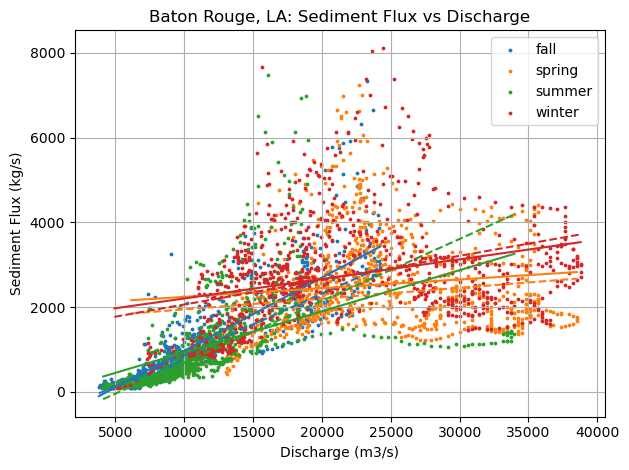

In [38]:
#%%Figure: Sediment flux vs discharge (colored by seasons)

lin_reg(seasonal_flux_table_whole['discharge_m3/s'], seasonal_flux_table_whole['sediment_flux_kg/s'],
        xlabel='Discharge (m3/s)', ylabel='Sediment Flux (kg/s)',
        title='Baton Rouge, LA: Sediment Flux vs Discharge')

Discussion: This figure is to represent the discharge vs sediment flux per season. This was explored after seeing the first plot in the study to see if there were any seasonal patterns after seeing there was annual seasonality. Upon observation it seems that summer and fall had lower values while spring and winter had the higher values. It is important to note that the more northern latitudes have stronger seasonality compared to the southern latitudes, but overall the Mississippi is influenced from Minnesota down to Louisiana.

Winter = 1f77b4 = red, r-value: 0.858, p-value: 5.131e-244 & 3.851e-246. Overall, the winter has the largest range in values, but notably yields the highest values. While reading the Wolman & Miller paper of 1960, they said, "Snow-fed rivers commonly carry their maximum discharges during the spring melt season and their largest sediment loads during heavy rains of summer and fall." However, in this study it shows that the "winter" had the highest sediment flux, possibly March captured the early melt. The r-value shows a very strong correlation, meaning the the sediment flux is strongly correlated to the discharge, possibly related to large floods from snow melt or storms moving a lot of sediment. The p-value is ~0 meaning it is extremely significant. Discharge is an indicator of sediment flux, meaning they are correlated.  *Winter months show the strongest correlation!

Spring = ff7f0e = orange, r-value: 0.120, p-value: 3.457e-04 &  6.779e-07. Overall, the spring's ranges seem to fall in the middle and higher values, which is to be expected from the winter melt and spring showers. However, the r-value (smallest of the seasons) shows a weak correlation meaning there is little correlation and sensitvity of sediment flux vs discharge, possibly because the flows are moderate or sporadic and/or the sediment supply is limited/variable (ice still melting, thaw, plant regrowth). The p-value is statistically significant (largest p-values of the seasons) but with the r-value so low the relationship is weak and could be more reliant on the data amount and not what the data is saying.  

Summer = 2ca02c = green, r-value: 0.494, p-value: 2.134e-55 & 6.240e-202. The summer values tended to show lower values, but also showed the most range in the x & y direction, such as there is an area showing high discharge but low sediment flux. Then, there is another area showing high sediment flux and mid-range discharge (15,000-20,000 m3/s). The r-value shows a moderate correlation, while the p value shows high significance. This could be interpreted that there is a moderate response of the sediment flux to discharge beacuse of storms triggering pulses (high sediment fluxes), or overall higher discharge rates from higher rainfall for a season. 

Fall = d62728 = blue, r-value: 0.302, p-value: 5.037e-20 & 5.229e-33. The fall values tended to be similar to those shown in the summer months, but had slightly higher values in sediment flux compared to discharge. The r-value showed a weak-moderate correlation (less than that of summer), meaning moderate correlation between discharge and sediment flux for the fall season. The p-values are highly significant but the relationship is weak. The interpretation of this is that the fall months have some sediment flux influence to the discharge, but there are other factors influencing just about as much, possibly small storms or harvesting (less soil stability). 

Summary: There is annual seasonality in the data, including seasonal variation in the sediment transport. Winter was the dominating season for peak sediment flux  with spring closely following, while the spring & summer showing a weaker signals. The winter was the only season that statistically could be concluded that its sediment flux was driven by discharge, while the other seasons had other influences. The other influences were most likely storm driven pulses, but others could be rainfall amount, plant regrowth, and irrigation during agricultural months. Tying this into socioeconomic relations, it would be best to prepare for flooding events in the winter and spring months. Looking upriver is the best warning when can get, so knowing when the snow melt is happening in the north will be amplified downstream, the same goes for storm events. 

-----------
Plot of seasonal sediment flux & seasonal discharge vs water year (a different visualization of the sediment flux vs discharge)

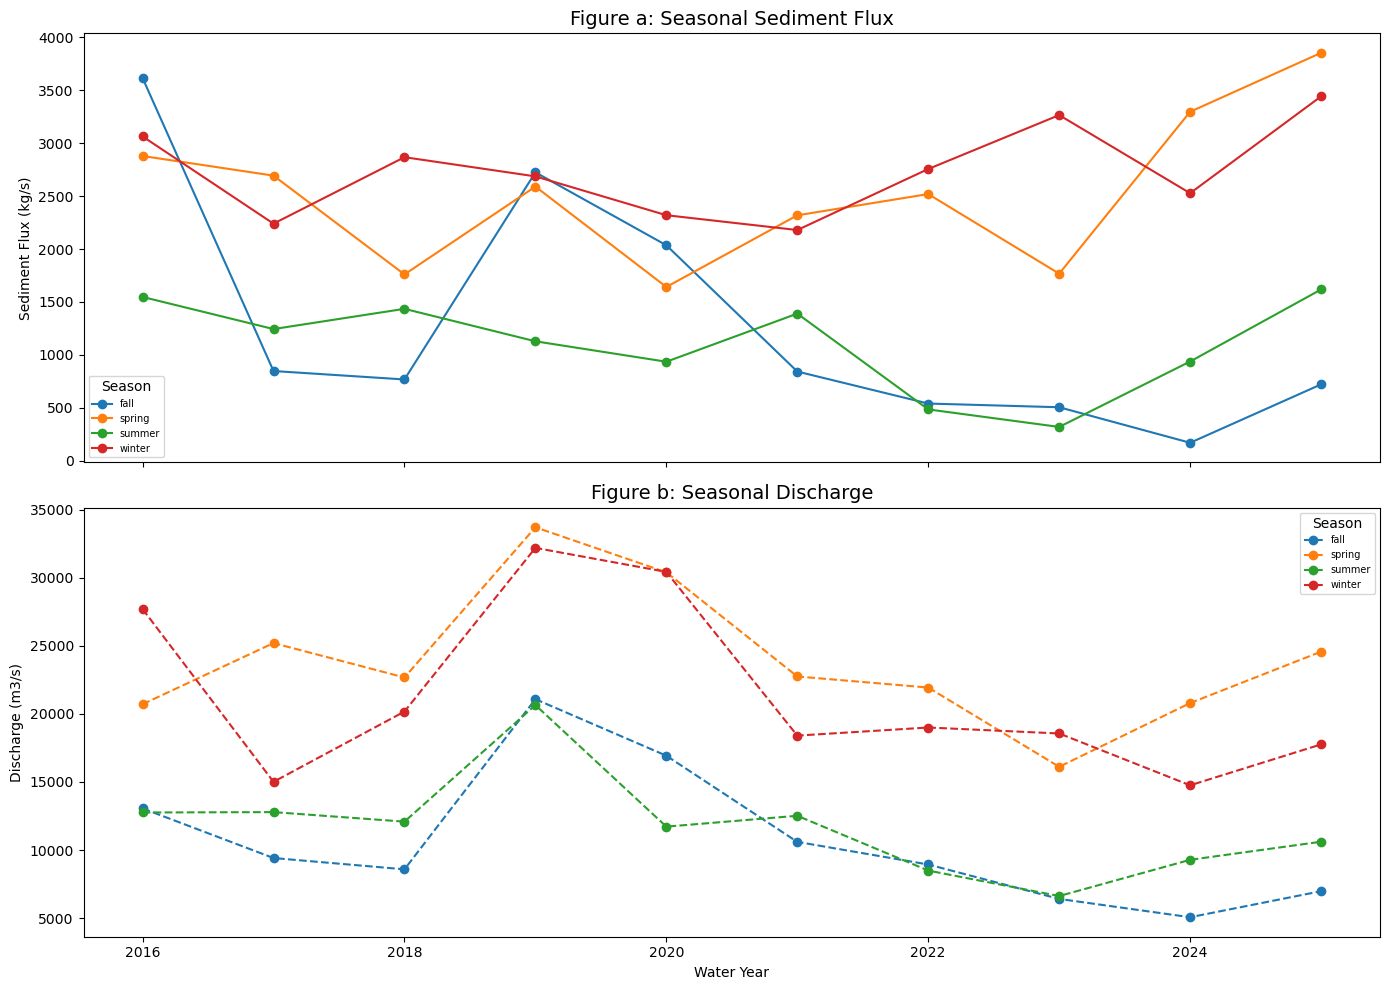

In [39]:
#%%Subplot Figure of seasonal sed flux and discharge 

fig, axs = plt.subplots(2,1,figsize=(14, 10), sharex=True)
axs = axs.flatten()


axs[0].set_title("Figure a: Seasonal Sediment Flux", fontsize=14) #sediment flux seasonal 

for season in seasonal_flux_table['sediment_flux_kg/s'].columns:
    axs[0].plot(seasonal_flux_table.index, seasonal_flux_table['sediment_flux_kg/s'][season],
    marker='o',label=season)
    
axs[0].set_ylabel("Sediment Flux (kg/s)")
axs[0].legend(title="Season", fontsize=7)


axs[1].set_title("Figure b: Seasonal Discharge", fontsize=14) #seasonal discharge 

for season in seasonal_flux_table['discharge_m3/s'].columns:
    axs[1].plot(seasonal_flux_table.index,seasonal_flux_table['discharge_m3/s'][season],
    marker='o', linestyle="--",label=season)

axs[1].set_ylabel("Discharge (m3/s)")
axs[1].set_xlabel("Water Year")
axs[1].legend(title="Season", fontsize=7)

plt.tight_layout()
plt.show()

Discussion: This figure was created to further investigate the seasonal differences of sediment flux and discharge, so what is shown are the 4 seasons plotted based on sediment flux for that season only over the study's time period in figure a & then again but for discharge in figure b. This figure's purpose was to visualize what was going on in the previous sediment flux vs discharge linear regression plot. It helps to better understand the relationship between seasonality, discharge, and sediment flux. 

Discussion of Figure A: Showing the separate seasons of sediment flux plotted over the water years. Overall, winter and spring have the highest sediment fluxes, which was seen in the previous figure. Summer has the least noisy data and shows a smaller magnitude of sediment flux. Fall has the largest range and noisiest signal over time, but shows a mid range of magnitude in sediment flux.  

Discussion of Figure B: Above shows the discharge separated by season. Both spring and winter are about the same magnitude of discharge, while the seasons of summer and fall having roughly half the amount of discharge. 

Overall Discussion: It can be seen that the four seasons can be binned into two groups,larger and smaller magnitudes. The larger magnitude of sediment flux and discharge being spring and winter, while the smaller magnitude being fall and summer. It is seen there is a stronger mirrored signal in the smaller magnitudes of fall and summer between the two plots. The mirroring at higher magnitudes of discharge shows little to no mirroring with the sediment flux. During the water years of 2018-2020 when the discharge went above 27500 m3/s there was not an increase in sediment flux, it was not mirrored, this has been shown in all three figures. There is a pattern that moderate discharges yield higher sediment loads. Lastly, it seems that overtime that discharge trended downwards but sediment flux trended upwards, and this will later be tested for significance in the next section of the project. 

------
Results from this section:
- The Mississippi River's discharge and sediment flux amount is affected by seasonal changes.
- There is a moderately strong relationship between discharge and sediment flux. In general, as discharge increases so does the sediment flux, but this fails above discharge amounts of 27500 m3/s. Above that discharge amount sediment flux decreases. The reason for this phenomenon is not concluded in this project.
- Winter & Spring yielded the largest magnitudes of discharge & sediment flux over the study period. There should be an emphasis on alerting and preparing the public of flooding during this time. Also, this is when the most sediment is moving through the Mississippi for deposition into the Gulf of Mexico. 

------
Plot average sediment flux (per water year) vs water year

Questions: How has the sediment flux to the Gulf of Mexico via the Mississippi River changed over the last ten years? Has the sediment flux increased or decreased throughout the study?

#1f77b4
slope: -30.180
intercept: 62879.392
r-value: -0.235
p-value: 5.127e-01
standard error: 44.056
95% CI slope: [-118.292, 57.933]
 Theil–Sen regression:
 slope: -31.923
 intercept: 66235.376
 95% CI slope: [-108.399, 28.457]
 Kendall Tau correlation: -0.244
  p-value: 3.807e-01


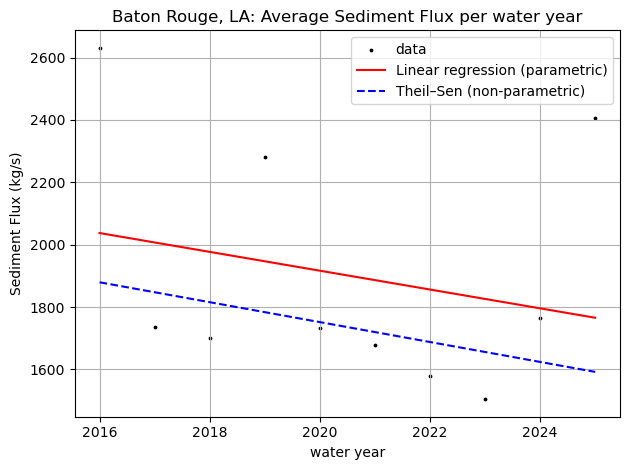

In [40]:
#%%Figure average sediment flux per water year vs water year

sed_flux_avg = good_data.groupby('wateryear')['sediment_flux_kg/s'].mean() #taking avg sed flux per water year 

lin_reg(sed_flux_avg.index, sed_flux_avg.values,
        xlabel='water year', ylabel='Sediment Flux (kg/s)',
        title='Baton Rouge, LA: Average Sediment Flux per water year')


Discussion: This figure shows the average sediment flux per individual water years throughout the study. This figure is critical in aiding to answer the research question, "How has the sediment flux to the Gulf of Mexico via the Mississippi River changed over the last ten years?" It is important to remember that annual averages include all the data inclduing the seasons and variability in events, such as floods, storms, sediment pulses, and land use changes.

Statistics Discussion: The negative slope of this figure is deceiving in the story it is telling, at a first glance it seems that sediment flux has decreased over the study period, but that is statistically not proven. The r-value is telling, being -0.235, meaning a weak correlation and little to no significance of sediment flux decreasing overtime. The p-values = 0.5127 & 0.3807, being not significant, and any apparent increase/decrease in sediment flux over time is therefore indistinguishable to any hypothesis that it would be significant. When looking at the data points they seem to have a randomness and a lot of noise to them showing the variability in annual sediment fluxes over the study period.

Question:  How has the sediment flux to the Gulf of Mexico via the Mississippi River changed over the last ten years? 

Answer : There is no statistical conclusion to come to for the answer of this question, but it can stated that over the last ten years there has been large variability in annual sediment fluxes of the Mississippi River. 

Question: Has the sediment flux increased or decreased throughout the study? 

 Answer : It cannot be supported that sediment deposition to the Gulf of Mexico via the Mississippi river has signficantly increased or decreased over time.

Further Discussion: In the news & literature there is continued talk that the areas around the Mississippi River's depostion area into the Gulf of Mexico are sinking. Here is a quote from an abstract, "The installation of flood-protection levees eliminated overbank sediment deposition and created an annual basin-wide sediment deficit, leading to land loss of 7 km² yr⁻¹," the paper is titled "Land loss due to human-altered sediment budget in the Mississippi River Delta" by Edmonds et Al. 2023. This is one of many papers with results supporting land loss due to decreased sediment deposition. However, in this study that conclusion was not supported. This study was minisucle in its parameters of measuring annual sediment flux and deposition amounts from the Mississippi, with many uncertainities in calculations, and therefore should not be heavily emphasized in its scientific outcomes. 

-----------------------------------------------------
SEDIMENT TRANSPORT & WOLMAN & MILLER PLOT

$$
C = a\,Q^{b}
$$

One of the most widely applied C-Q analyses is the power-law relationship (C = aQ^b), where C (concentration) and Q (discharge) are regressed in log-log space, and the parameters a (y-intercept) and b (slope) are derived.

$$
T = a\,Q^{b}
$$

Wolman & Miller use a derived equation from the one above, the transport formula : 𝑇 = aQ^b , Where : T = sediment transport, Q = discharge, a, b = coefficients from fitting log–log regression. 

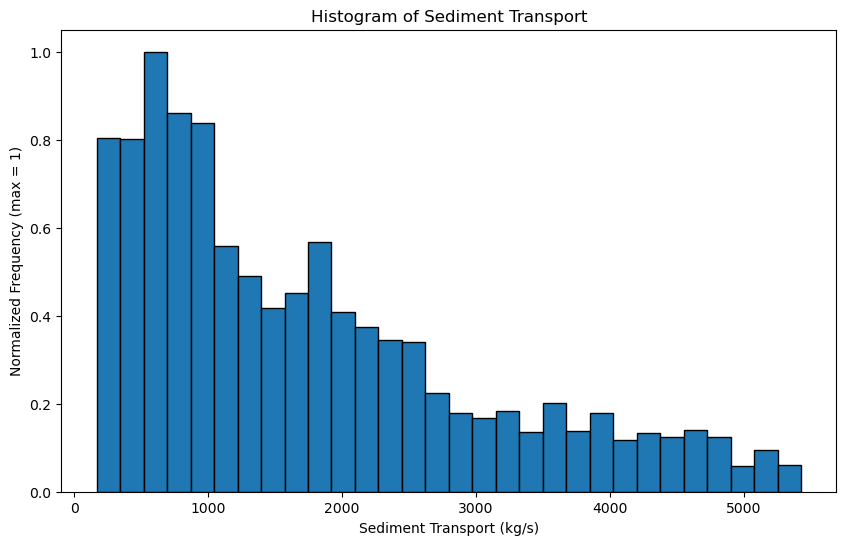

In [41]:
#%%Histogram of Sediment Transport (T = a*Q**b)

histogram_data = good_data['sed_transport_kg/s'].dropna()

counts, bin_edges = np.histogram(histogram_data, bins=30) #making histogram & setting parameters 

counts_norm = counts / counts.max()  # Normalizing so max bar = 1

#The peak (most common sediment transport value) will show as 1
#All other bars represent a fraction of that peak

# Plot #did use AI to help me plot this histogram (for example :the counts, bin edges, and width)
plt.figure(figsize=(10,6))
plt.bar(bin_edges[:-1], counts_norm, width=np.diff(bin_edges), edgecolor='black', align='edge')

plt.title("Histogram of Sediment Transport", fontsize=12)
plt.xlabel("Sediment Transport (kg/s)")
plt.ylabel("Normalized Frequency (max = 1)")
plt.show()


Discussion: The above figure shows a histogram of sediment transport vs frequency. The y-axis has been normalized to 1.0, meaning that the tallest bar is the most frequent sediment transport. Therefore, any bars below the tallest happen less frequently, in other words the height relates to its proportion of frequency. This figure was made to explore the relationship between concentration and discharge, concentration being sediment transport in this case. Sediment transport is calculated based off sediment flux and discharge. This figure has two large takeaways...
- Most frequently there are lower sediment transport events (~500-1000kg/s). This can be understood as the most common sediment transport conditions of the Mississippi River. 
- Less frequently there are large sediment transport events (floods & storms) but these events carry large influential amounts of sediment on rare occurences. 

Summary: The frequency peaks with low to moderate sediment transport. This aligns with a concept from Wolman & Miller's paper from 1960, "the extreme velocities associated with infrequent events are compensated for by their rarity, and it is found that the greatest bulk of sediment is transported by more moderate events." When trying to understand the annual sediment deposition it can be concluded that the majority of the sediment transport happens cumulatively with regular river flow,and in addition to that, the rare event occurences may surpass sediment transport. Overall, it is vital to account for all frequency of events when trying to calculate the sediment deposition of the Mississippi River. 

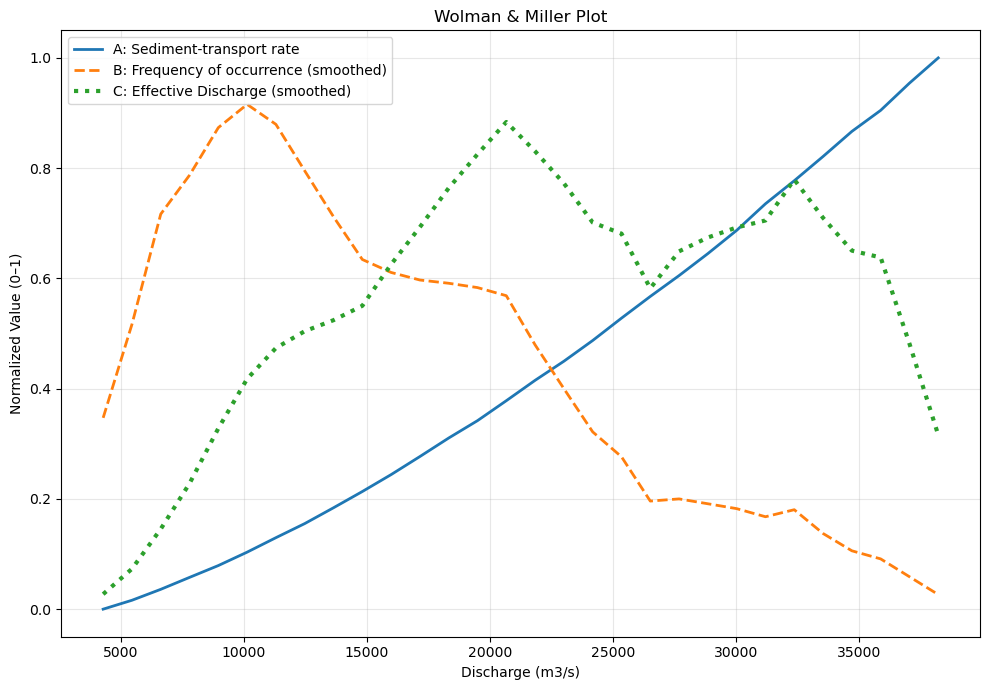

In [42]:
#%%Wolman and Miller plot
#used AI to help me with this 

Q  = good_data['discharge_m3/s'] 
ST = good_data['sed_transport_kg/s']

mask = (Q > 0) & (ST > 0) & np.isfinite(Q) & np.isfinite(ST)
Q = Q[mask]
ST = ST[mask]

num_bins = 30 #binning the discharge 
counts, edges = np.histogram(Q, bins=num_bins)
centers = (edges[:-1] + edges[1:]) / 2

freq = counts / counts.sum() #the probability (frequency)

sed_bin = []  #binning sediment transport 
for i in range(len(edges)-1):
    data = ST[(Q >= edges[i]) & (Q < edges[i+1])] #lining up bins correctly 
    sed_bin.append(data.mean() if len(data)>0 else np.nan)

sed_bin = np.array(sed_bin)

effective_discharge = freq * sed_bin #calculating effective discharge = frquency * sediment transport 

def normalize(x): #Normalize all curves to 0-1 scale 
    return (x - np.nanmin(x)) / (np.nanmax(x) - np.nanmin(x))

sed_norm = normalize(sed_bin) #normalizing sed transport
freq_norm = normalize(freq) #normalizing frquency 
eff_norm = normalize(effective_discharge) #normalizing effective discharge 

def moving_average(x, window=3):   #moving average to help with smoothing the data 
    return np.convolve(x, np.ones(window)/window, mode='same')

freq_smooth = moving_average(freq_norm, window=5) #moving average ->smoothing #smoothing frequency 
eff_smooth = moving_average(eff_norm, window=5) #smoothin effective discharge 

plt.figure(figsize=(10,7))
plt.plot(centers, sed_norm, label="A: Sediment-transport rate", linewidth=2)
plt.plot(centers, freq_smooth, label="B: Frequency of occurrence (smoothed)", linestyle="--", linewidth=2)
plt.plot(centers, eff_smooth, label="C: Effective Discharge (smoothed)", linestyle=":", linewidth=3)

plt.xlabel("Discharge (m3/s)")
plt.ylabel("Normalized Value (0–1)")
plt.title("Wolman & Miller Plot")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Discussion: This is the final and cumulative plot of the project involving many aspects the data. First, the layout of the figure before the analysis.
- A : Sediment-transport rate curve (blue), showing how much sediment the Mississippi River can carry per discharge rate.
- B : Frequency of occurence (orange), showing the frequency of occurence (normalized to 1.0) of the discharge over the study period. 
- C : Effective Discharge (green), where sediment transport peaks per certain discharge rate. 
The data was smoothed in this figure using a moving average to eliminate the noisiness in the data to aid in visualization and to see more apparent trends.

Discussion: The sediment-transport rate shows that theoretically with increased discharge there is increased sediment transport, but in nature there is not theoretical perfection, also seen in these data results. In contrast, the frequency of occurence shows a trend of low to moderate discharges occuring most commonly, and high discharges increasingly more rare (large storms and floods). The effective discharge curve is a product of the sediment transport rate and the frequency of occurence. It displays the discharge rates that move the most sediment, where it is "most effective." At its peak is the ideal discharge rate for moving sediment. Therefore knowing the effective discharge rate or rates can help scientists know when the river may be moving large masses of sediment for deposition. Below the effective discharge sediment transport capacity is not being maximized, while above, the peak effective discharge sediment transport capacity increases but frequency decreases.

Results: 
- The most frequent occurence of dischagre peaks at 10,000 m3/s. The common trend shows the frequency of occurence decreases with increasing discharge after this peak. In general, frequency peaks with moderate discharges.
- Effective Discharge peaks at ~21,000 m3/s and then again at ~32,000 m3/s. At these discharge rates the greatest proportion of sediment transport is happening. Below peak discharge the sediment transport is not maximized by lower discharge, while above peak effective discharge more sediment can be transported, but it is limited by frequency of the Mississippi River reaching that discharge. 
- This data follows the classic Wolman & Miller magnitude-frequency concept, that moderate and frequent discharges move the majority of sediment. 

In [43]:
#%%seasonal sediment transport 

seasonal_flux_table = good_data.pivot_table(index='wateryear',columns='season',
                      values=['sediment_flux_kg/s','discharge_m3/s','sed_transport_kg/s'])
print(seasonal_flux_table) #simplified version to see values of the discharge per water year and its seasonal values, also for sed flux, and sed transport 
seasonal_flux_table_whole = good_data.pivot_table(index= good_data.index,columns='season',
                      values=['sediment_flux_kg/s','discharge_m3/s','sed_transport_kg/s'])
 #extended version of daily data within a season to see values of the discharge per water year and its seasonal values, also for sed flux, and sed transport 


          discharge_m3/s                                            \
season              fall        spring        summer        winter   
wateryear                                                            
2016        13056.814922  20718.251218  12757.641774  27715.923727   
2017         9410.719130  25212.531903  12785.650783  15011.679573   
2018         8580.298191  22683.312668  12085.117774  20178.866311   
2019        21086.474470  33724.997626  20654.643270  32210.045369   
2020        16931.599652  30414.732589  11717.614957  30443.049389   
2021        10597.562400  22757.371991  12516.641183  18409.695573   
2022         8935.181565  21943.964132   8488.576383  19005.606898   
2023         6404.213670  16116.615631   6615.666296  18566.067236   
2024         5058.550087  20802.579270   9279.292243  14756.475710   
2025         6971.473043  24581.782963  10608.531270  17762.499378   

          sed_transport_kg/s                                         \
season            

Conclusion: This project examined hydrologic data analysis of the Mississippi River over the most recent ten water years (2015-2025). The data analysis's main focus was on examining the annual sediment flux of the Mississippi into the Gulf of Mexico over the last ten years. It was concluded that there was no signficant increase or decrease in annual sediment flux over the study. It was expected that there would be a decrease in annual sediment flux due to what was being said in the literature, but in this study it cannot be statistically concluded. However, the results from this study should not skew one's view of the importance of the issue at hand, anthropogenic influence of the Mississippi has caused drastic changes in the nearby landscape. The coastal areas near the Mississippi output are withering away from seaward inundation due to impacted sediment deposition from levees, locks, and dams. Also, the floodplains along the Mississippi have been negatively impacted from the installation of leeves. The levees prevent overbank flooding to the region, but the flooding process is what delivered critical sediment and nutrients to the ecosystem, supplying the input. Without the input of sediment to these regions erosional processes dominate and overrule the landscape resulting in land and ecosystem loss. Though, it was not seen that significant sediment deposition has decreased over years in this study, there were other takeaways. One of them being that within the annual seasonality of the data, there were higher discharges and sediment fluxes in the winter and spring, most likely from snow melt and spring precipitation. During this period it would be best to alert the public of flooding. With flooding comes higher discharges and increased sediment transport, but with a caveat, discharges above 27500 m3/s do not yield higher sediment transport, it fails beyond this. The answer to this was not concluded in this study, but a theory is that at higher discharges there is a dilluting affect to the sediment vs water. It was seen in this study that the most sediment transport happens at moderate discharges. However, when calculating the annual sediment transport budget it is most important to study both the frequent moderate discharges and the infrequent large events (floods/storms/possible dam failures). Overall, the past 10-year annual sediment deposition of the Mississippi River to the Gulf of Mexico cannot be answered in this simplistic overview of this study, but continued research and restoration processes should be continued to serve the ecosystem, landscape, and people affected by this problem.

----------------------------------------------------------------------------------------------------------
Work Cited 

Edmonds, Douglas A., et al. “Land Loss Due to Human-Altered Sediment Budget in the Mississippi River Delta.” Nature Sustainability, vol. 6, no. 6, 2023, pp. 644–651, doi:10.1038/s41893-023-01081-0.

Harringmeyer, J. P., Ghosh, N., Weiser, M. W., Thompson, D. R., Simard, M., Lohrenz, S. E., & Fichot, C. G. (2024). A hyperspectral view of the nearshore Mississippi River Delta: characterizing suspended particles in coastal wetlands using imaging spectroscopy. Remote Sensing of Environment, 301, 113943, https://doi.org/10.1016/j.rse.2023.113943.

Wolman, M. Gordon, and John P. Miller. Magnitude and Frequency of Forces in Geomorphic Processes. Journal of Geology, vol. 68, no. 1, 1960, pp. 54–74

Wymore, Adam S., et al. "Revisiting the Origins of the Power-Law Analysis for the Assessment of Concentration-Discharge Relationships." Water Resources Research, vol. 59, no. 8, July 2023, e2023WR034910. AGU Publications, doi:10.1029/2023WR034910. 